In [99]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
images = Path('datasets')
outputs = Path('outputs/sift/')
sfm_pairs = outputs / 'pairs-sfm.txt'
# loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

# feature_conf = extract_features.confs['disk']
# matcher_conf = match_features.confs['disk+lightglue']
# matcher_conf = match_features.confs['superglue']

feature_conf = extract_features.confs['sift']
matcher_conf = match_features.confs['NN-ratio']


3 mapping images


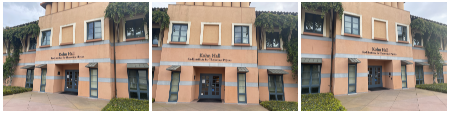

In [101]:
references = [str(p.relative_to(images)) for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [ ]:
# extract_features.main(feature_conf, images, image_list=references, feature_path=features)
# pairs_from_exhaustive.main(sfm_pairs, image_list=references)
# match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches)

In [103]:
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def load_image(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_features(features_h5, key):
    with h5py.File(features_h5, 'r') as f_feat:
        kpts = [None] * len(key)
        for i,k in enumerate(key):
            if k in f_feat:
                kpts[i] = f_feat[k]['keypoints'][:]
            else:
                raise KeyError(f"Key '{k}' not found in {features_h5}")
    return kpts

def load_matches(matches_h5, key1, key2):
    with h5py.File(matches_h5, 'r') as f_match:
        if key1 in f_match and key2 in f_match[key1]:
            matches = f_match[key1][key2]['matches0'][:]
        elif key2 in f_match and key1 in f_match[key2]:
            matches = f_match[key2][key1]['matches0'][:]
        else:
            raise KeyError(f"No matches found for '{key1}' and '{key2}'")
    return matches


def visualize_keypoints(image_path, h5_file, key):
    img = load_image(image_path)
    keypoints = load_features(h5_file, [key])[0]
    for (x, y) in keypoints:
        cv2.circle(img, (int(x), int(y)), 10, (0, 255, 0), -1)
    plt.figure(figsize=(8, 6))
    plt.title(f"Keypoints: {key}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()


def visualize_matches(image_path1, image_path2, key1, key2, features_h5, matches_h5):
    img1 = load_image(image_path1)
    img2 = load_image(image_path2)

    kpts1, kpts2 = load_features(features_h5, [key1, key2])

    matches = load_matches(matches_h5, key1, key2)

    valid = matches > -1
    matched_kpts1 = kpts1[valid]
    matched_kpts2 = kpts2[matches[valid]]

    # Combine two images side by side
    height = max(img1.shape[0], img2.shape[0])
    combo = np.zeros((height, img1.shape[1] + img2.shape[1], 3), dtype=np.uint8)
    combo[:img1.shape[0], :img1.shape[1]] = img1
    combo[:img2.shape[0], img1.shape[1]:] = img2

    for pt1, pt2 in zip(matched_kpts1, matched_kpts2):
        pt1 = tuple(np.round(pt1).astype(int))
        pt2 = tuple(np.round(pt2).astype(int) + np.array([img1.shape[1], 0]))
        cv2.line(combo, pt1, pt2, (255, 0, 0), 3)

    plt.figure(figsize=(12, 6))
    plt.title(f"Matches: {key1} ↔ {key2} ({len(matched_kpts1)} matches)")
    plt.imshow(combo)
    plt.axis('off')
    plt.show()


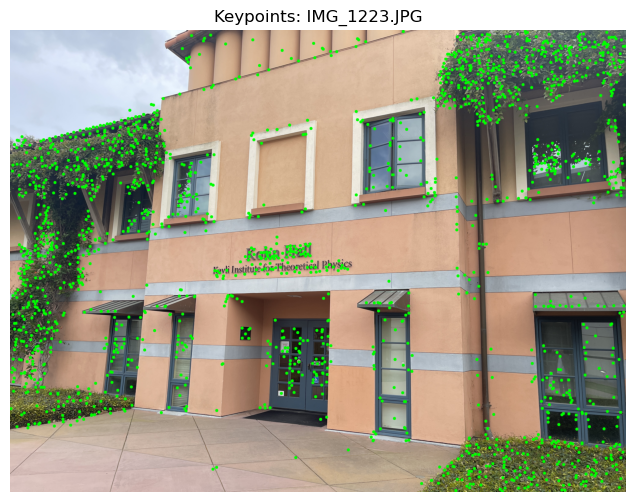

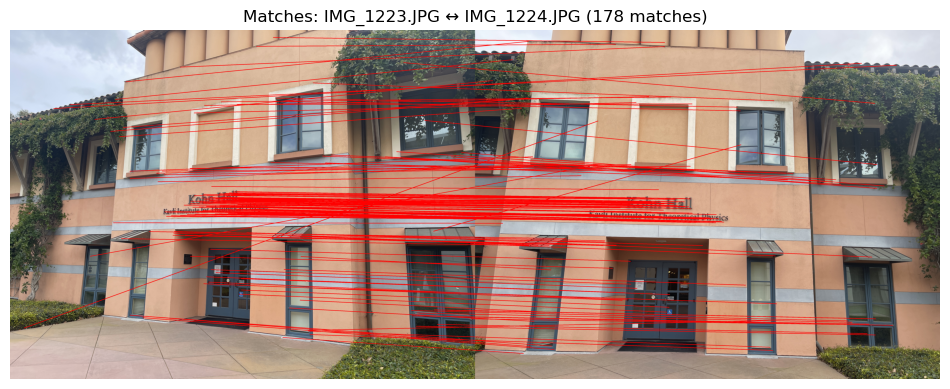

In [104]:
images_dir = Path("datasets")
features_path = str(features)
matches_path = str(matches)

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"

img1_path = images_dir / key1
img2_path = images_dir / key2

# 可视化关键点
visualize_keypoints(img1_path, features_path, key1)

# 可视化匹配点
visualize_matches(img1_path, img2_path, key1, key2, features_path, matches_path)


In [130]:
%load_ext autoreload
%autoreload 2

# import import_ipynb
import cv2
import m1

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"
key3 = "IMG_1226.JPG"
features_path = "outputs/SuperPoints/features.h5"
matches_path = "outputs/SuperPoints/matches.h5"

img_1 = cv2.imread("datasets\IMG_1223.JPG")
img_2 = cv2.imread("datasets\IMG_1224.JPG")
img_3 = cv2.imread("datasets\IMG_1226.JPG")

kpts1, kpts2, kpts3 = load_features(features_path, [key1, key2, key3])
matches12 = load_matches(matches_path, key1, key2)
matches23 = load_matches(matches_path, key2, key3)
matches13 = load_matches(matches_path, key1, key3)

valid = matches12 > -1
matched12_kpts1 = kpts1[valid]
matched12_kpts2 = kpts2[matches12[valid]]

valid = matches23 > -1
matched23_kpts2 = kpts2[valid]
matched23_kpts3 = kpts3[matches23[valid]]

valid = matches13 > -1
matched13_kpts1 = kpts1[valid]
matched13_kpts3 = kpts3[matches13[valid]]

# H_12 = m1.compute_homography_dlt_normalized(matched12_kpts1, matched12_kpts2)
# H_23 = m1.compute_homography_dlt_normalized(matched23_kpts2, matched23_kpts3)
# H_13 = m1.compute_homography_dlt_normalized(matched13_kpts1, matched13_kpts3)
# print("H_12:\n", H_12)
# print("H_23:\n", H_23)
# print("H_13:\n", H_13)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
# F_12 = m1.compute_fundamental_matrix_normalized(matched12_kpts1, matched12_kpts2)
# F_23 = m1.compute_fundamental_matrix_normalized(matched23_kpts2, matched23_kpts3)
# F_13 = m1.compute_fundamental_matrix_normalized(matched13_kpts1, matched13_kpts3)

# print("F_12:\n", F_12)
# print("F_23:\n", F_23)
# print("F_13:\n", F_13)

In [132]:
# m1.draw_epipolar_lines(img_1, img_2, img_3, kpts1[:100], kpts2[:100], kpts3[:100], F_12, F_13)

In [133]:

# database_path = "outputs/sift/database.db"
# features_h5_path = "outputs/sift/features.h5"

# img1_path = "datasets/IMG_1223.JPG"
# img2_path = "datasets/IMG_1224.JPG"

# image_id1 = 1  # 你根据实际情况设定ID
# image_id2 = 2

# image_name1 = "IMG_1223.JPG"
# image_name2 = "IMG_1224.JPG"

# # ====== 读数据库 matches ======
# matches_dict = read_matches_from_db(database_path)
# matches = matches_dict.get((image_id1, image_id2), None)
# if matches is None:
#     print(f"No matches between {image_id1} and {image_id2}")

# # ====== 读图和关键点 ======
# img1 = cv2.imread(img1_path)
# img2 = cv2.imread(img2_path)
# kpts1 = load_keypoints(features_h5_path, image_name1)
# kpts2 = load_keypoints(features_h5_path, image_name2)

# pts1 = kpts1[np.arange(len(matches))]    # source keypoints
# pts2 = kpts2[matches]                    # destination keypoints
# print(f"Number of matches: {len(matches)}")
# print(f"Keypoints in image 1: {len(kpts1)}.",f"inlier ratio1: {len(matches) / len(kpts1):.2f}")
# print(f"Keypoints in image 2: {len(kpts2)}.",f"inlier ratio2: {len(matches) / len(kpts2):.2f}")

# # H, mask_H = cv2.findHomography(pts1, pts2)
# # print("Homography matrix H:\n", H)

# # F, mask_F = cv2.findFundamentalMat(pts1, pts2)
# # print("Fundamental matrix F:\n", F)

Homography matrix H_12:
 [[ 2.29939699e+00 -2.70865232e-02 -1.71917155e+03]
 [ 5.46057948e-01  1.60223272e+00 -1.15923752e+03]
 [ 2.53358119e-04 -1.61299357e-05  1.00000000e+00]]
ratio of inliers: 178 / 1671
Mean reprojection error after applying H: 1.6861 pixels


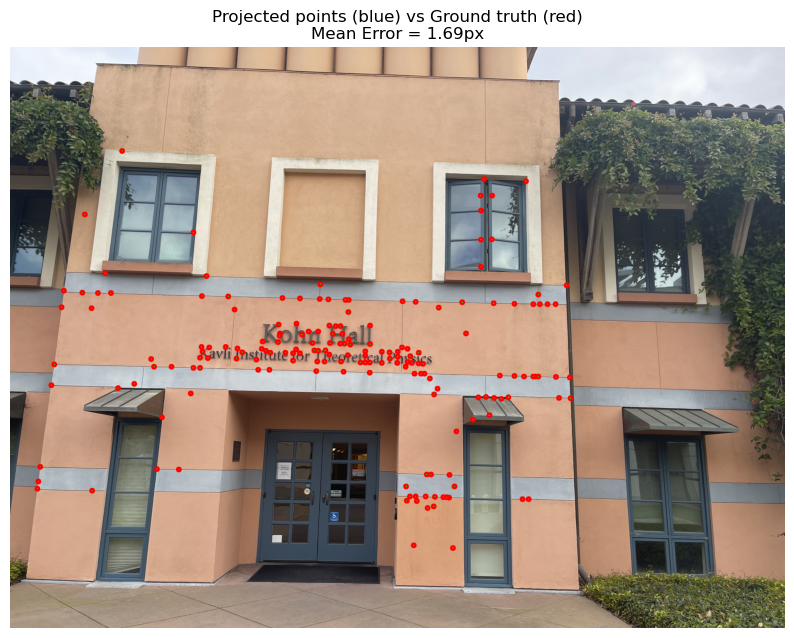

1.6861172517712757

In [134]:
def verify_homography(H, pts1, pts2, img2=None):
    """
    验证H变换后pts1是否与pts2对齐，并可视化。
    """
    # 将pts1变成齐次坐标 (N,3)
    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])  # (N, 3)
    projected_pts1 = (H @ pts1_h.T).T  # (N, 3)
    projected_pts1 /= projected_pts1[:, [2]]  # 归一化
    projected_pts1 = projected_pts1[:, :2]

    # 计算每个点的欧式距离
    errors = np.linalg.norm(projected_pts1 - pts2, axis=1)
    mean_error = np.mean(errors)

    print(f"Mean reprojection error after applying H: {mean_error:.4f} pixels")

    # ===== 可视化部分 =====
    if img2 is not None:
        img_vis = img2.copy()

        for pt_proj, pt_gt in zip(projected_pts1, pts2):
            pt_proj = tuple(np.round(pt_proj).astype(int))
            pt_gt = tuple(np.round(pt_gt).astype(int))

            # 画投影点
            cv2.drawMarker(img_vis, pt_proj, (255, 0, 0), markerType=cv2.MARKER_TILTED_CROSS, markerSize=10, thickness=10)
            # 画真实点
            cv2.circle(img_vis, pt_gt, radius=15, color=(0, 0, 255), thickness=-1)
            # 画连接线
            cv2.line(img_vis, pt_proj, pt_gt, color=(0, 255, 0), thickness=3)

        # 显示
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Projected points (blue) vs Ground truth (red)\nMean Error = {mean_error:.2f}px")
        plt.axis('off')
        plt.show()

    return mean_error

H_12, mask_H = cv2.findHomography(matched12_kpts1, matched12_kpts2, method=cv2.RANSAC, ransacReprojThreshold=3.0)
print("Homography matrix H_12:\n", H_12)

pts1_inliers = matched12_kpts1[mask_H.ravel() == 1] #extract inliers from mask
pts2_inliers = matched12_kpts2[mask_H.ravel() == 1]

print(f"ratio of inliers: {len(pts1_inliers)} / {len(matched12_kpts1)}")
# print(f"ratio of inliers: {len(pts2_inliers)} / {len(matched12_kpts2)}")

verify_homography(H_12, pts1_inliers, pts2_inliers, img_2)


Fundamental matrix F_12:
 [[-5.19420677e-09  3.77708842e-08 -9.74964185e-05]
 [ 1.94085180e-07 -1.92626346e-08  1.05030773e-03]
 [-3.73203659e-04 -1.58424713e-03  1.00000000e+00]]
ratio of inliers: 920 / 1671
Mean epipolar error:   1.272 px
Median epipolar error: 1.162 px
Max epipolar error:    2.993 px


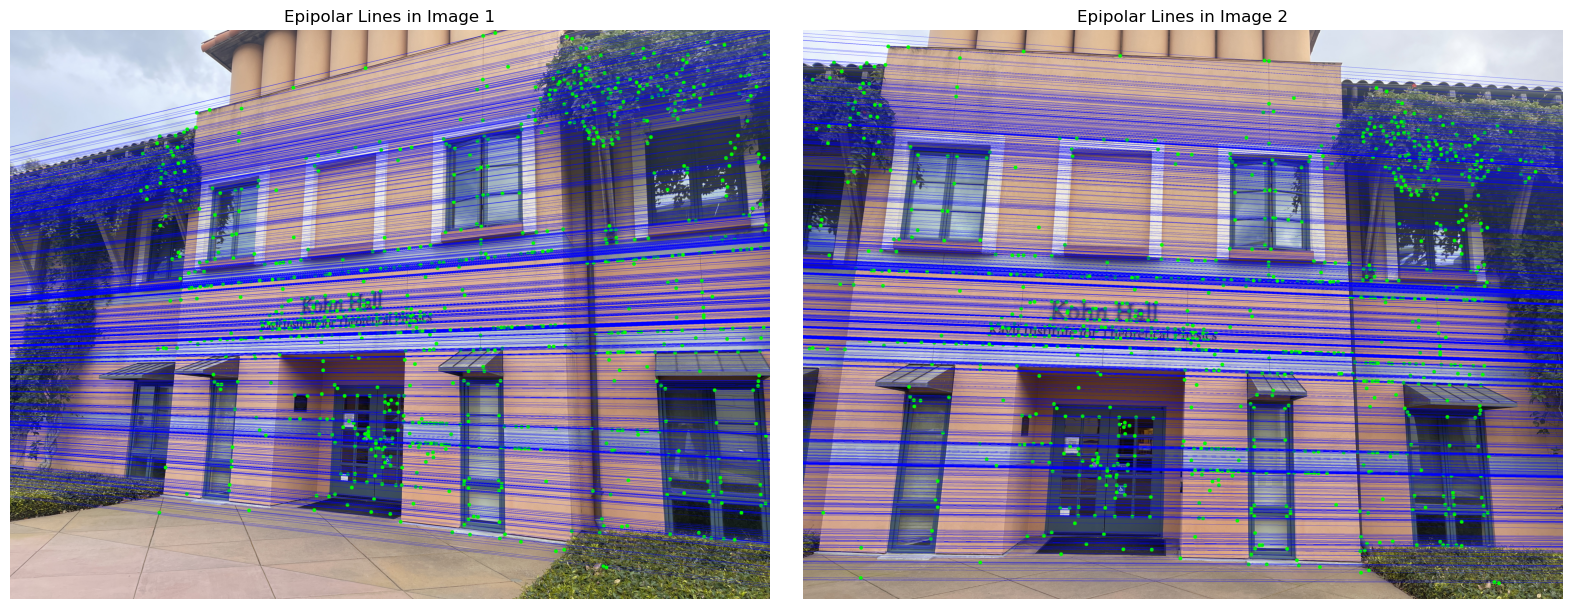

In [135]:
def draw_epipolar_lines(F, img1, img2, pts1_inliers, pts2_inliers):
    # F, mask = cv2.findFundamentalMat(pts1, pts2, method=cv2.FM_RANSAC)
    # print("Fundamental Matrix:\n", F)
    # pts1_inliers = pts1[mask.ravel() == 1]
    # pts2_inliers = pts2[mask.ravel() == 1]

    # print(f"ratio of inliers: {len(pts1_inliers) / len(matched12_kpts1):.2f}")
    # print(f"ratio of inliers: {len(pts2_inliers) / len(matched12_kpts2):.2f}")

    lines1 = cv2.computeCorrespondEpilines(pts2_inliers.reshape(-1, 1, 2).astype(np.float32), 2, F)
    lines2 = cv2.computeCorrespondEpilines(pts1_inliers.reshape(-1, 1, 2).astype(np.float32), 1, F)

    lines1 = lines1.reshape(-1, 3)
    lines2 = lines2.reshape(-1, 3)

    img1_vis = img1.copy()
    img2_vis = img2.copy()

    for r, pt in zip(lines1, pts1_inliers):
        a, b, c = r
        x0, y0 = map(int, [0, -c / b])
        x1, y1 = map(int, [img1.shape[1], -(c + a * img1.shape[1]) / b])
        cv2.line(img1_vis, (x0, y0), (x1, y1), (255, 0, 0), 1)
        cv2.circle(img1_vis, tuple(np.round(pt).astype(int)), 10, (0, 255, 0), -1)

    for r, pt in zip(lines2, pts2_inliers):
        a, b, c = r
        x0, y0 = map(int, [0, -c / b])
        x1, y1 = map(int, [img2.shape[1], -(c + a * img2.shape[1]) / b])
        cv2.line(img2_vis, (x0, y0), (x1, y1), (255, 0, 0), 1)
        cv2.circle(img2_vis, tuple(np.round(pt).astype(int)), 10, (0, 255, 0), -1)

    plt.figure(figsize=(16, 6))
    plt.subplot(121)
    plt.imshow(cv2.cvtColor(img1_vis, cv2.COLOR_BGR2RGB))
    plt.title("Epipolar Lines in Image 1")
    plt.axis('off')
    plt.subplot(122)
    plt.imshow(cv2.cvtColor(img2_vis, cv2.COLOR_BGR2RGB))
    plt.title("Epipolar Lines in Image 2")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def compute_epipolar_errors(pts1, pts2, F):
    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
    pts2_h = np.hstack([pts2, np.ones((pts2.shape[0], 1))])
    lines2 = (F @ pts1_h.T).T
    numerators = np.abs(np.sum(lines2 * pts2_h, axis=1))
    denominators = np.sqrt(lines2[:, 0]**2 + lines2[:, 1]**2) #perpendicular distance
    return numerators / denominators

F_12, mask = cv2.findFundamentalMat(matched12_kpts1, matched12_kpts2, method=cv2.FM_RANSAC)
print("Fundamental matrix F_12:\n", F_12)

pts1_inliers = matched12_kpts1[mask.ravel() == 1] #extract inliers from mask
pts2_inliers = matched12_kpts2[mask.ravel() == 1]

print(f"ratio of inliers: {len(pts1_inliers)} / {len(matched12_kpts1)}")
# print(f"ratio of inliers: {len(pts2_inliers)} / {len(matched12_kpts2)}")

errors = compute_epipolar_errors(pts1_inliers, pts2_inliers, F_12)
print(f"Mean epipolar error:   {np.mean(errors):.3f} px")
print(f"Median epipolar error: {np.median(errors):.3f} px")
print(f"Max epipolar error:    {np.max(errors):.3f} px")

draw_epipolar_lines(F_12, img_1, img_2, pts1_inliers, pts2_inliers)

In [136]:
from build_database import build_database

build_database(
    features_h5_path="outputs/SuperPoints/features.h5",
    matches_h5_path="outputs/SuperPoints/matches.h5",
    output_db_path="outputs/SuperPoints/database.db"
)


Processing matches: 100%|██████████| 11/11 [00:00<00:00, 208.63it/s]

Saved pruned matches to outputs\SuperPoints\database.db
